In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import shap
from sklearn.model_selection import cross_val_score
import joblib

In [3]:
df = pd.read_csv(r"/content/wind turbine data set.csv")
df.head()

,TurbineID,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure,FaultType
0,T56,23.9,12.3,34,98,77,0.98,936,65,27,143,0,NaN
1,T46,12.6,17.6,27,84,86,0.70,1517,74,33,221,0,NaN
2,T47,22.4,18.0,30,94,86,0.76,1460,73,16,151,0,NaN
3,T79,12.9,18.0,27,71,88,0.74,1134,68,32,169,0,NaN
4,T16,8.6,13.8,27,79,93,1.33,1485,79,21,180,1,Generator


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TurbineID                 9000 non-null   object 
 1   WindSpeed                 9000 non-null   float64
 2   RotorSpeed                9000 non-null   float64
 3   BladeAngle                9000 non-null   int64  
 4   GearboxTemp               9000 non-null   int64  
 5   GeneratorTemp             9000 non-null   int64  
 6   Vibration                 9000 non-null   float64
 7   PowerOutput               9000 non-null   int64  
 8   Humidity                  9000 non-null   int64  
 9   AmbientTemperature        9000 non-null   int64  
 10  TimeSinceLastMaintenance  9000 non-null   int64  
 11  Failure                   9000 non-null   int64  
 12  FaultType                 1152 non-null   object 
dtypes: float64(3), int64(8), object(2)
memory usage: 914.2+ KB


In [5]:
df.describe()

,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,14.972944,15.014489,30.020556,85.066222,85.121000,1.001574,1447.854556,70.033556,24.961667,164.715444,0.128000
std,5.786175,2.882054,8.685036,8.653435,5.783124,0.290811,319.898071,5.742907,5.756860,77.479453,0.334108
min,5.000000,10.000000,15.000000,70.000000,75.000000,0.500000,900.000000,60.000000,15.000000,30.000000,0.000000
25%,9.900000,12.500000,23.000000,78.000000,80.000000,0.750000,1171.000000,65.000000,20.000000,98.750000,0.000000
50%,14.900000,15.100000,30.000000,85.000000,85.000000,1.000000,1441.000000,70.000000,25.000000,164.000000,0.000000
75%,20.000000,17.500000,38.000000,93.000000,90.000000,1.260000,1728.000000,75.000000,30.000000,232.000000,0.000000
max,25.000000,20.000000,45.000000,100.000000,95.000000,1.500000,2000.000000,80.000000,35.000000,299.000000,1.000000


In [6]:
df.shape

(9000, 13)

In [7]:
df.columns

Index(['TurbineID', 'WindSpeed', 'RotorSpeed', 'BladeAngle', 'GearboxTemp',
       'GeneratorTemp', 'Vibration', 'PowerOutput', 'Humidity',
       'AmbientTemperature', 'TimeSinceLastMaintenance', 'Failure',
       'FaultType'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
TurbineID,0
WindSpeed,0
RotorSpeed,0
BladeAngle,0
GearboxTemp,0
GeneratorTemp,0
Vibration,0
PowerOutput,0
Humidity,0
AmbientTemperature,0


In [9]:
df.describe()

,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,14.972944,15.014489,30.020556,85.066222,85.121000,1.001574,1447.854556,70.033556,24.961667,164.715444,0.128000
std,5.786175,2.882054,8.685036,8.653435,5.783124,0.290811,319.898071,5.742907,5.756860,77.479453,0.334108
min,5.000000,10.000000,15.000000,70.000000,75.000000,0.500000,900.000000,60.000000,15.000000,30.000000,0.000000
25%,9.900000,12.500000,23.000000,78.000000,80.000000,0.750000,1171.000000,65.000000,20.000000,98.750000,0.000000
50%,14.900000,15.100000,30.000000,85.000000,85.000000,1.000000,1441.000000,70.000000,25.000000,164.000000,0.000000
75%,20.000000,17.500000,38.000000,93.000000,90.000000,1.260000,1728.000000,75.000000,30.000000,232.000000,0.000000
max,25.000000,20.000000,45.000000,100.000000,95.000000,1.500000,2000.000000,80.000000,35.000000,299.000000,1.000000


In [10]:
df[df['FaultType'].isnull()]['Failure'].value_counts()

,count
Failure,
0,7848


In [11]:
df['FaultType'] = df['FaultType'].fillna('No Fault')

In [12]:
df.isnull().sum()

,0
TurbineID,0
WindSpeed,0
RotorSpeed,0
BladeAngle,0
GearboxTemp,0
GeneratorTemp,0
Vibration,0
PowerOutput,0
Humidity,0
AmbientTemperature,0


In [13]:
df['FaultType'].value_counts()

,count
FaultType,
No Fault,7848
Gearbox,586
Blades,314
Generator,252


In [14]:
df['TempDiff'] = df['GearboxTemp'] - df['GeneratorTemp']
df['PowerEfficiency'] = df['PowerOutput'] / ((df['WindSpeed']**3) + 1)
df['VibrationPerSpeed'] = df['Vibration'] / (df['RotorSpeed'] + 1)
df['MaintenanceRisk'] = df['TimeSinceLastMaintenance'] * df['Vibration']
df.head()

,TurbineID,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure,FaultType,TempDiff,PowerEfficiency,VibrationPerSpeed,MaintenanceRisk
0,T56,23.9,12.3,34,98,77,0.98,936,65,27,143,0,No Fault,21,0.068557,0.073684,140.14
1,T46,12.6,17.6,27,84,86,0.70,1517,74,33,221,0,No Fault,-2,0.757979,0.037634,154.70
2,T47,22.4,18.0,30,94,86,0.76,1460,73,16,151,0,No Fault,8,0.129888,0.040000,114.76
3,T79,12.9,18.0,27,71,88,0.74,1134,68,32,169,0,No Fault,-17,0.528009,0.038947,125.06
4,T16,8.6,13.8,27,79,93,1.33,1485,79,21,180,1,Generator,-14,2.331035,0.089865,239.40


In [15]:
le = LabelEncoder()
df['FaultType'] = le.fit_transform(df['FaultType'])

In [ ]:
cols = [
    'Vibration',
    'GearboxTemp',
    'GeneratorTemp',
    'WindSpeed',
    'RotorSpeed',
    'BladeAngle'
]

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[~((df[cols] < lower) | (df[cols] > upper)).any(axis=1)]

In [16]:
#EDA

In [17]:
df.describe()

,WindSpeed,RotorSpeed,BladeAngle,GearboxTemp,GeneratorTemp,Vibration,PowerOutput,Humidity,AmbientTemperature,TimeSinceLastMaintenance,Failure,FaultType,TempDiff,PowerEfficiency,VibrationPerSpeed,MaintenanceRisk
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,14.972944,15.014489,30.020556,85.066222,85.121000,1.001574,1447.854556,70.033556,24.961667,164.715444,0.128000,2.737111,-0.054778,1.391262,0.064684,164.726368
std,5.786175,2.882054,8.685036,8.653435,5.783124,0.290811,319.898071,5.742907,5.756860,77.479453,0.334108,0.730338,10.348436,2.244044,0.022620,93.171166
min,5.000000,10.000000,15.000000,70.000000,75.000000,0.500000,900.000000,60.000000,15.000000,30.000000,0.000000,0.000000,-25.000000,0.058108,0.024038,15.900000
25%,9.900000,12.500000,23.000000,78.000000,80.000000,0.750000,1171.000000,65.000000,20.000000,98.750000,0.000000,3.000000,-8.000000,0.177631,0.046667,89.787500
50%,14.900000,15.100000,30.000000,85.000000,85.000000,1.000000,1441.000000,70.000000,25.000000,164.000000,0.000000,3.000000,0.000000,0.423703,0.062436,149.725000
75%,20.000000,17.500000,38.000000,93.000000,90.000000,1.260000,1728.000000,75.000000,30.000000,232.000000,0.000000,3.000000,8.000000,1.467156,0.079262,226.002500
max,25.000000,20.000000,45.000000,100.000000,95.000000,1.500000,2000.000000,80.000000,35.000000,299.000000,1.000000,3.000000,25.000000,14.912698,0.134234,439.530000


In [18]:
df.corr(numeric_only=True)['Failure'].sort_values(ascending=False)

,Failure
Failure,1.000000
Vibration,0.379540
VibrationPerSpeed,0.313193
MaintenanceRisk,0.203140
GearboxTemp,0.169604
BladeAngle,0.164989
WindSpeed,0.132504
GeneratorTemp,0.098552
TempDiff,0.086749
PowerOutput,0.008950


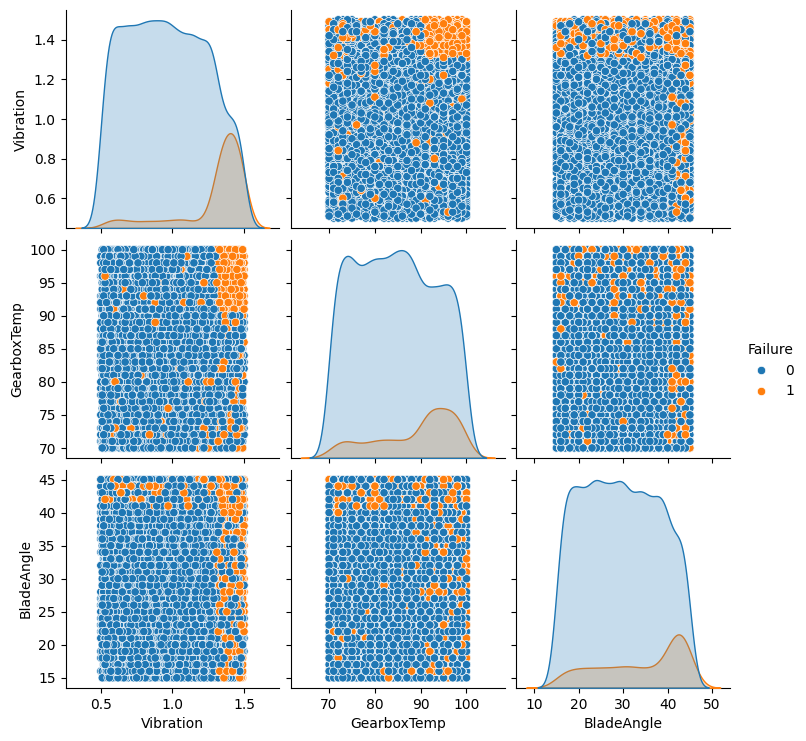

In [19]:
import seaborn as sns

sns.pairplot(df[['Vibration', 'GearboxTemp', 'BladeAngle', 'Failure']], hue='Failure')

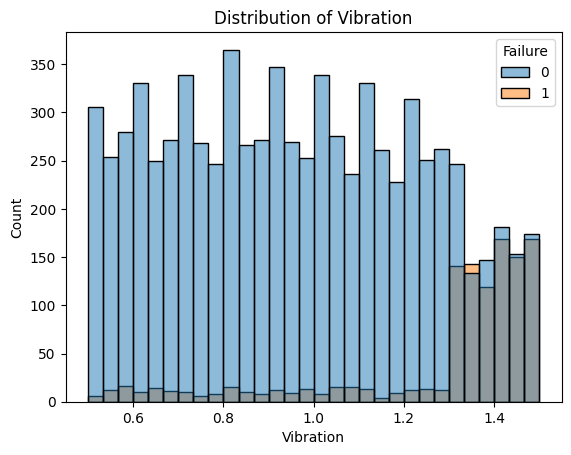

In [20]:
sns.histplot(data=df, x='Vibration', hue='Failure', bins=30)
plt.title("Distribution of Vibration")
plt.show()

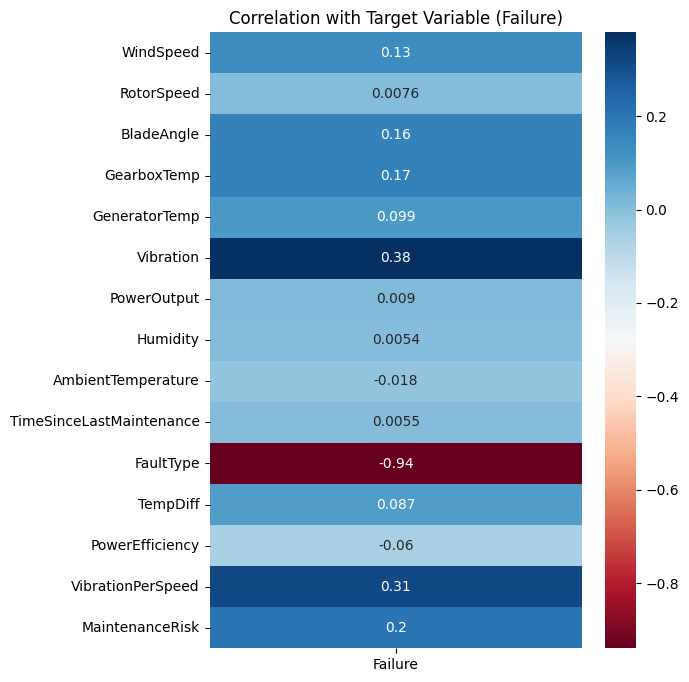

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)['Failure'].drop('Failure')

plt.figure(figsize=(6,8))
sns.heatmap(corr.to_frame(), annot=True, cmap='RdBu', cbar=True)
plt.title("Correlation with Target Variable (Failure)")
plt.show()

**Model Selection & Training**

In [22]:
# Use only core sensor features
drop_cols = [
    'Failure',
    'FaultType',
    'TurbineID',
    'PowerEfficiency'
]

X = df.drop(columns=drop_cols)
y = df['Failure']

print(X.columns)
print(X.shape)

Index(['WindSpeed', 'RotorSpeed', 'BladeAngle', 'GearboxTemp', 'GeneratorTemp',
       'Vibration', 'PowerOutput', 'Humidity', 'AmbientTemperature',
       'TimeSinceLastMaintenance', 'TempDiff', 'VibrationPerSpeed',
       'MaintenanceRisk'],
      dtype='object')
(9000, 13)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
y_train.value_counts()
y_test.value_counts()

,count
Failure,
0,1575
1,225


**Logistic Regression**

In [25]:
model = LogisticRegression(max_iter=1000)

In [26]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [28]:
y_pred = model.predict(X_test)

In [29]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy*100)

Accuracy: 79.38888888888889


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.79      0.87      1575
           1       0.36      0.84      0.50       225

    accuracy                           0.79      1800
   macro avg       0.67      0.81      0.69      1800
weighted avg       0.90      0.79      0.82      1800



**Decision Tree**

In [31]:
model = DecisionTreeClassifier(
        max_depth=2,
        min_samples_leaf=20,
        min_samples_split=25,
        class_weight='balanced',
        random_state=42
    )

In [32]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred)*100)

Accuracy: 81.38888888888889


In [34]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.79      0.88      1575
           1       0.40      1.00      0.57       225

    accuracy                           0.81      1800
   macro avg       0.70      0.89      0.73      1800
weighted avg       0.93      0.81      0.84      1800



In [35]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
print("AUC:", roc_auc_score(y_test, y_prob))

AUC: 0.94514708994709


**Random Forest**

In [36]:
model = RandomForestClassifier(
        n_estimators=80,
        max_depth=3,
        min_samples_leaf=2,
        min_samples_split=6,
        class_weight='balanced',
        random_state=42
    )

In [37]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=3, min_samples_leaf=2,
                       min_samples_split=6, n_estimators=80, random_state=42)

In [38]:
y_pred = model.predict(X_test)

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred)*100)

Accuracy: 90.16666666666666


In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94      1575
           1       0.56      1.00      0.72       225

    accuracy                           0.90      1800
   macro avg       0.78      0.94      0.83      1800
weighted avg       0.94      0.90      0.91      1800



In [41]:
y_prob = model.predict_proba(X_test)[:,1]
print("AUC:", roc_auc_score(y_test, y_prob))

AUC: 0.9913029982363315


**XG Boost**

In [42]:
model = XGBClassifier(
        n_estimators=50,
        max_depth=2,
        learning_rate=0.02,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=1,
        reg_lambda=2,
        eval_metric='logloss',
        random_state=42
    )

In [43]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.02, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=2, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

In [44]:
y_pred = model.predict(X_test)

In [45]:
print("Accuracy:", accuracy_score(y_test, y_pred)*100)

Accuracy: 92.0


In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1575
           1       1.00      0.36      0.53       225

    accuracy                           0.92      1800
   macro avg       0.96      0.68      0.74      1800
weighted avg       0.93      0.92      0.90      1800



**Fault** **Type** **Prediction**

In [47]:
model = XGBClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.02,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=2,
    eval_metric='logloss',
    random_state=42
)

In [48]:
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Scores:", scores)
print("Mean Accuracy:", scores.mean())

Scores: [0.92666667 0.92277778 0.91666667 0.90944444 0.92111111]
Mean Accuracy: 0.9193333333333333


In [49]:
scores = cross_val_score(model, X, y, cv=5, scoring='f1')

print("F1 Scores:", scores)
print("Mean F1:", scores.mean())

F1 Scores: [0.59756098 0.56697819 0.51612903 0.4548495  0.55625   ]
Mean F1: 0.5383535398683994


**Failure Type Prediction**

In [50]:
df_fault = df[df['Failure'] == 1]

In [51]:
X = df_fault.drop(['Failure', 'FaultType','TurbineID'], axis=1)
y = df_fault['FaultType']

In [52]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [54]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [55]:
y_pred = model.predict(X_test)

In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00       117
           2       1.00      1.00      1.00        51

    accuracy                           1.00       231
   macro avg       1.00      1.00      1.00       231
weighted avg       1.00      1.00      1.00       231



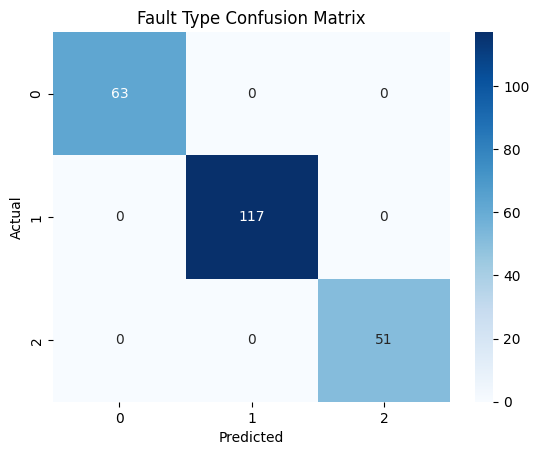

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fault Type Confusion Matrix")
plt.show()

**Hyperparameter Tuning**

In [58]:
param_dist = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
}

In [59]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

model = XGBClassifier(eval_metric='logloss', random_state=42)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,                 # number of combinations
    scoring='f1_weighted',              # important for imbalance
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [2, 3, 4, 5],
                                        'n_estimators': [50, 100, 150, 200],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='f1_weighted', verbose=1)

In [60]:
print("Best Params:", random_search.best_params_)

Best Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.8}


In [61]:
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        63
           1       1.00      1.00      1.00       117
           2       1.00      1.00      1.00        51

    accuracy                           1.00       231
   macro avg       1.00      1.00      1.00       231
weighted avg       1.00      1.00      1.00       231



**Post-Model Analysis:** **Feature Importance & Model Interpretability**

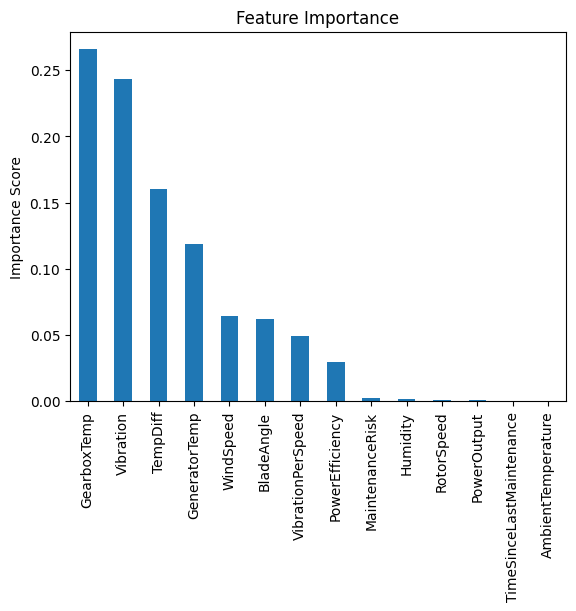

In [62]:
importance = best_model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

# Plot
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()

 93%|=================== | 3224/3456 [00:11<00:00]       

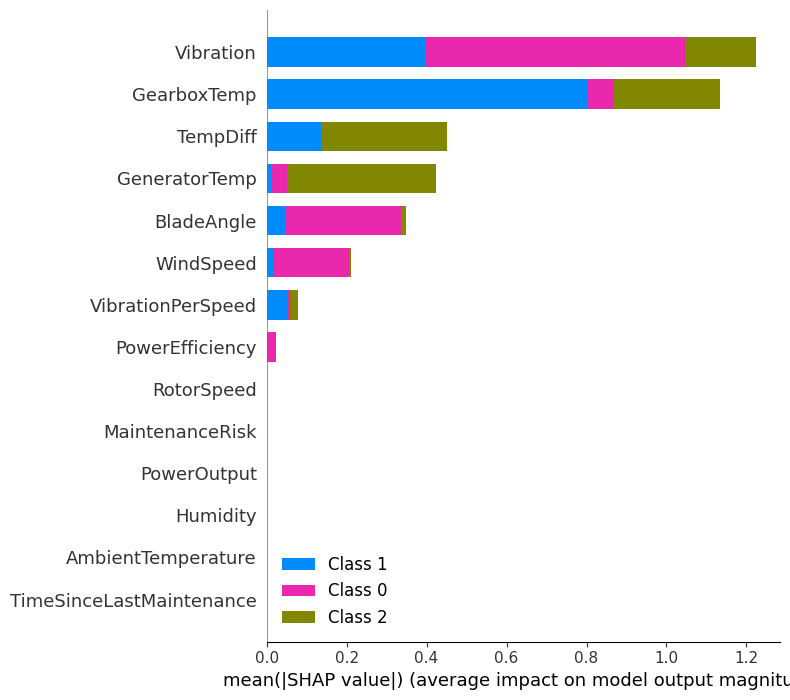

In [63]:
explainer = shap.Explainer(best_model, X)
shap_values = explainer(X)

shap.summary_plot(shap_values, X)

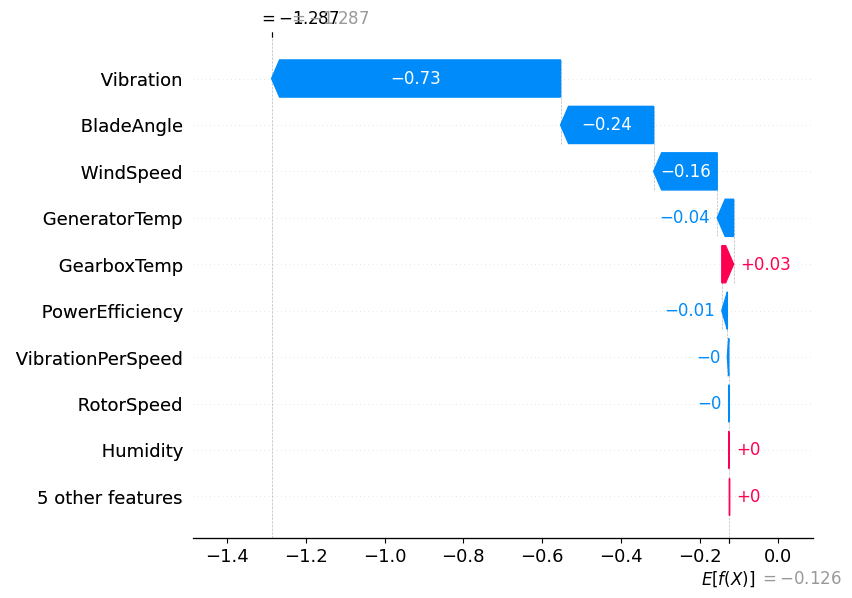

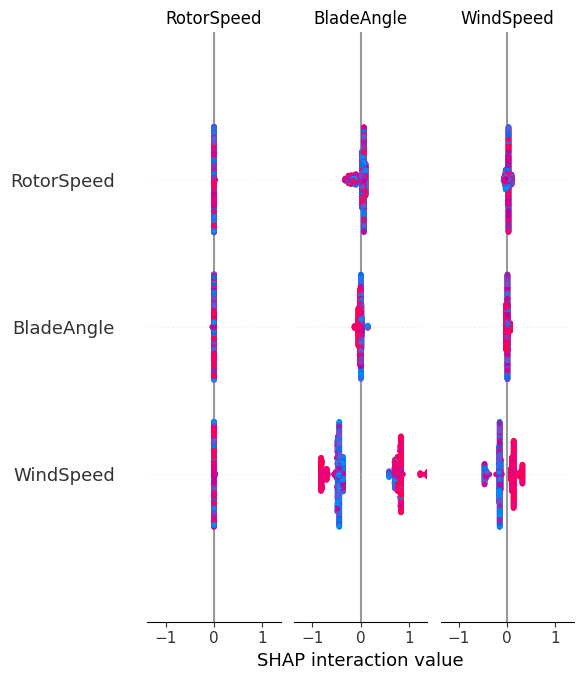

In [64]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[0],
    shap_values[0][:, 0],
    X.iloc[0]
)
shap.summary_plot(shap_values, X)

**Prediction**

In [65]:
import joblib

joblib.dump(best_model, "turbine_model.pkl")

['turbine_model.pkl']

In [66]:
model = joblib.load("turbine_model.pkl")

def predict_turbine(data):
    pred = model.predict(data)[0]

    if pred == 1:
        return "Failure Detected!"
    else:
        return "Turbine is Healthy"


print("Enter turbine values:")

wind = float(input("Wind Speed: "))
rotor = float(input("Rotor Speed: "))
blade = float(input("Blade Angle: "))
gear = float(input("Gearbox Temp: "))
gen = float(input("Generator Temp: "))
vib = float(input("Vibration: "))
power = float(input("Power Output: "))
hum = float(input("Humidity: "))
amb = float(input("Ambient Temp: "))
maint = float(input("Time Since Last Maintenance: "))
temp_diff = gear - gen
power_efficiency = power / (wind + 1e-5)
vibration_per_speed = vib / (rotor + 1e-5)
maintenance_risk = maint * vib


data = [[
    wind,
    rotor,
    blade,
    gear,
    gen,
    vib,
    power,
    hum,
    amb,
    maint,
    temp_diff,
    power_efficiency,
    vibration_per_speed,
    maintenance_risk
]]


result = predict_turbine(data)

print("\nPrediction Result:")
print(result)

Enter turbine values:
Wind Speed: 19
Rotor Speed: 20
Blade Angle: 35
Gearbox Temp: 92
Generator Temp: 95
Vibration: 1.4
Power Output: 1540
Humidity: 70
Ambient Temp: 30
Time Since Last Maintenance: 190

Prediction Result:
Failure Detected!
